In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Border-based distance

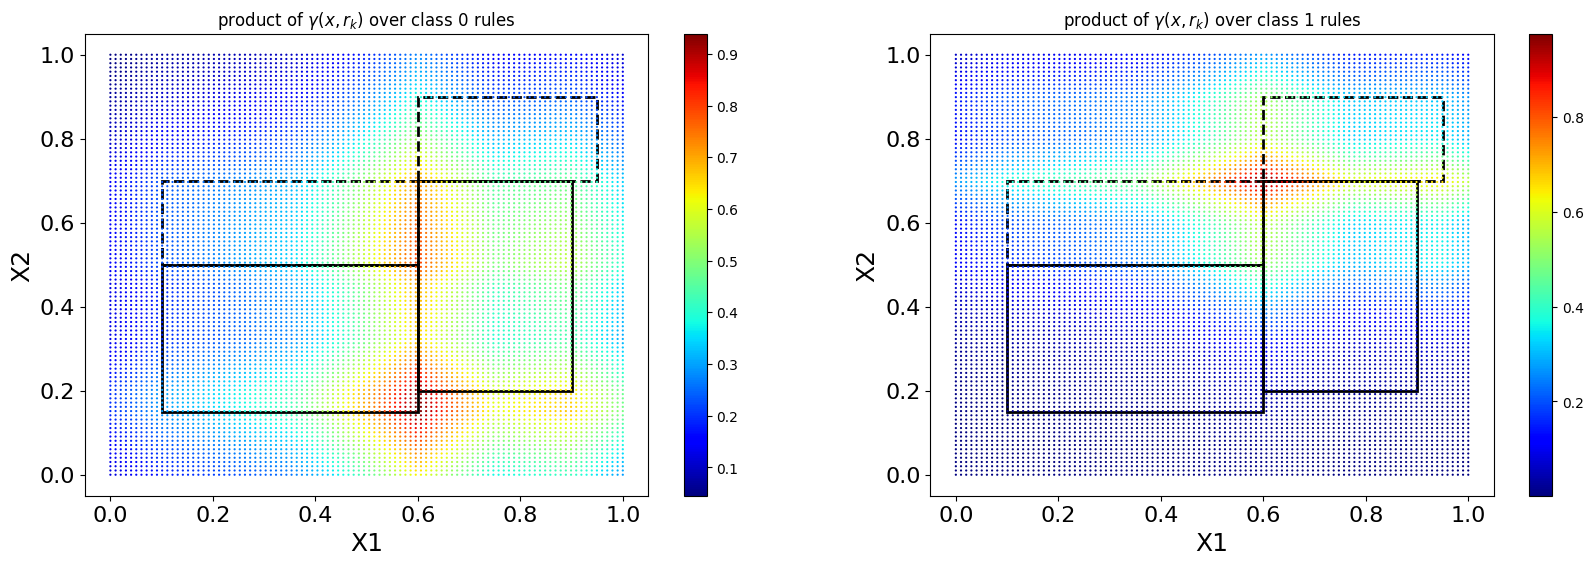

In [93]:
from matplotlib import colors

norm = colors.Normalize(vmin=0, vmax=1)

def compute_borderbased_gamma(rule_limits, X_r, Y_r, normalization = "tanh"):

    xmin, xmax, ymin, ymax = rule_limits

    dx = np.abs(xmax-xmin)#np.abs(np.maximum(xmax, X_r) - np.minimum(xmin, X_r))
    dy = np.abs(ymax-ymin)#np.abs(np.maximum(ymax, Y_r) - np.minimum(ymin, Y_r))

    gamma1 = np.abs(xmax - X_r) / dx
    gamma3 = np.abs(xmin - X_r) / dx
    gamma2 = np.abs(ymax - Y_r) / dy
    gamma4 = np.abs(ymin - Y_r) / dy

    average_min_gamma = np.mean([np.minimum(gamma1, gamma3),np.minimum(gamma2, gamma4)], axis=0)
    if normalization == "bounded":
        tau_geom = average_min_gamma/(1+average_min_gamma) 
    elif normalization == "tanh":
        tau_geom =  np.tanh(average_min_gamma)
        # return as nonconformity
    return 1-tau_geom

x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
X_r, Y_r = np.meshgrid(x, y)

rule_limits = [[0.1, 0.6, 0.15, 0.5], [0.6, 0.9, 0.2, 0.7], [0.1, 0.6, 0.5, 0.7], [0.6, 0.95, 0.7, 0.9]]
changeclsidx = 3
tau_geom_tot_0 = 1
for r in rule_limits[:changeclsidx-1]:
    tau_geom = compute_borderbased_gamma(r, X_r, Y_r)
    tau_geom_tot_0*=tau_geom



tau_geom_tot_1 = 1
for r in rule_limits[changeclsidx-1:]:
    tau_geom = compute_borderbased_gamma(r, X_r, Y_r)
    tau_geom_tot_1*=tau_geom


fig, (ax1, ax2) = plt.subplots(1,2,figsize = (20,6))
for idx, r in enumerate(rule_limits):
    xmin, xmax, ymin, ymax = r
    if idx < changeclsidx-1:
        ax1.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='-', facecolor='none'))
        ax2.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='-', facecolor='none'))
    else:
        ax1.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='--', facecolor='none'))

sc1 = ax1.scatter(X_r, Y_r, c=tau_geom_tot_0, cmap='jet', s=10, edgecolors='none', linewidth=1.5, marker='.')#, norm = norm)
cbar = plt.colorbar(sc1, ax=ax1)
ax1.set_xlabel("X1", fontsize=18)
ax1.set_ylabel("X2", fontsize=18)
ax1.set_title(r"product of $\gamma(x, r_k)$ over class 0 rules")
ax1.tick_params(labelsize=16)

sc2 = ax2.scatter(X_r, Y_r, c=tau_geom_tot_1, cmap='jet', s=10, edgecolors='none', linewidth=1.5, marker='.')#, norm = norm)
cbar = plt.colorbar(sc2, ax=ax2)
ax2.set_xlabel("X1", fontsize=18)
ax2.set_ylabel("X2", fontsize=18)
ax2.tick_params(labelsize=16)
ax2.set_title(r"product of $\gamma(x, r_k)$ over class 1 rules")
#fig.suptitle(r"Product of distances from borders")
plt.show()

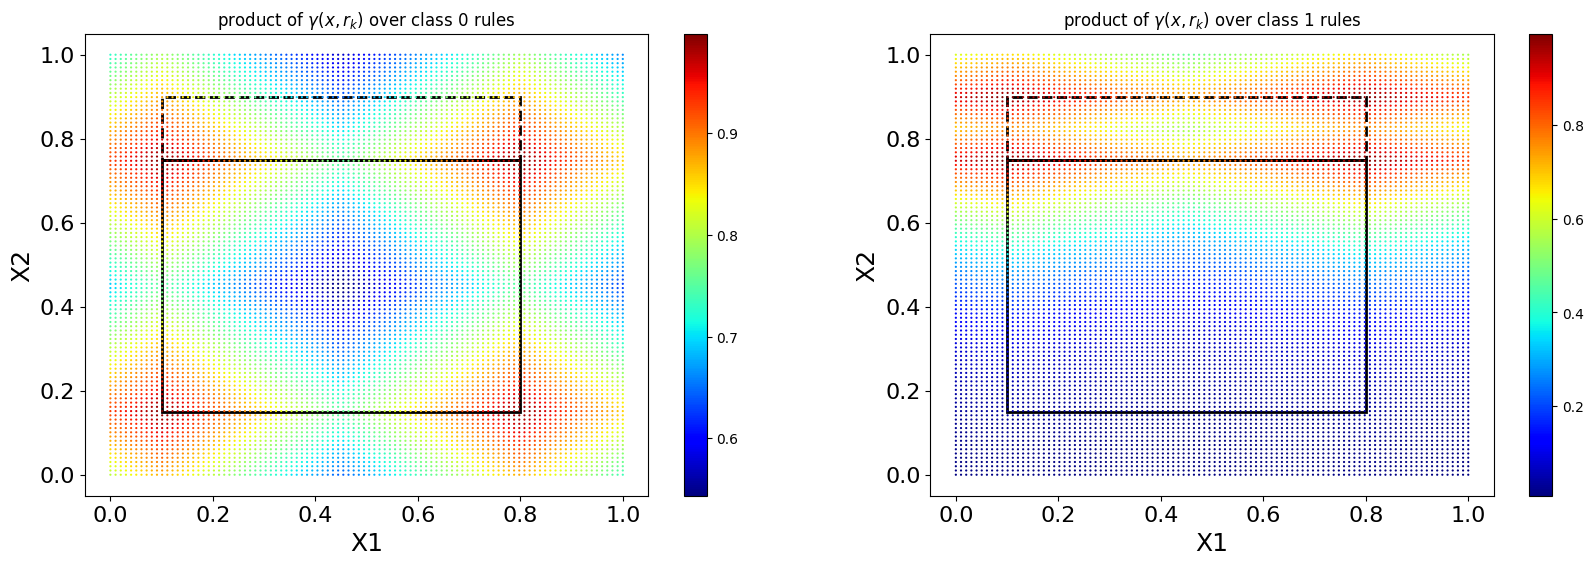

In [96]:
rule_limits = [[0.1, 0.8, 0.15, 0.75], [0.1, 0.8, 0.75, 0.9]]
changeclsidx = 2
tau_geom_tot_0 = 1
for r in rule_limits[:changeclsidx-1]:
    tau_geom = compute_borderbased_gamma(r, X_r, Y_r)
    tau_geom_tot_0*=tau_geom



tau_geom_tot_1 = 1
for r in rule_limits[changeclsidx-1:]:
    tau_geom = compute_borderbased_gamma(r, X_r, Y_r)
    tau_geom_tot_1*=tau_geom


fig, (ax1, ax2) = plt.subplots(1,2,figsize = (20,6))
for idx, r in enumerate(rule_limits):
    xmin, xmax, ymin, ymax = r
    if idx < changeclsidx-1:
        ax1.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='-', facecolor='none'))
        ax2.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='-', facecolor='none'))
    else:
        ax1.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='--', facecolor='none'))

sc1 = ax1.scatter(X_r, Y_r, c=tau_geom_tot_0, cmap='jet', s=10, edgecolors='none', linewidth=1.5, marker='.')#, norm = norm)
cbar = plt.colorbar(sc1, ax=ax1)
ax1.set_xlabel("X1", fontsize=18)
ax1.set_ylabel("X2", fontsize=18)
ax1.set_title(r"product of $\gamma(x, r_k)$ over class 0 rules")
ax1.tick_params(labelsize=16)

sc2 = ax2.scatter(X_r, Y_r, c=tau_geom_tot_1, cmap='jet', s=10, edgecolors='none', linewidth=1.5, marker='.')#, norm = norm)
cbar = plt.colorbar(sc2, ax=ax2)
ax2.set_xlabel("X1", fontsize=18)
ax2.set_ylabel("X2", fontsize=18)
ax2.tick_params(labelsize=16)
ax2.set_title(r"product of $\gamma(x, r_k)$ over class 1 rules")
#fig.suptitle(r"Product of distances from borders")
plt.show()

# Center-based distance

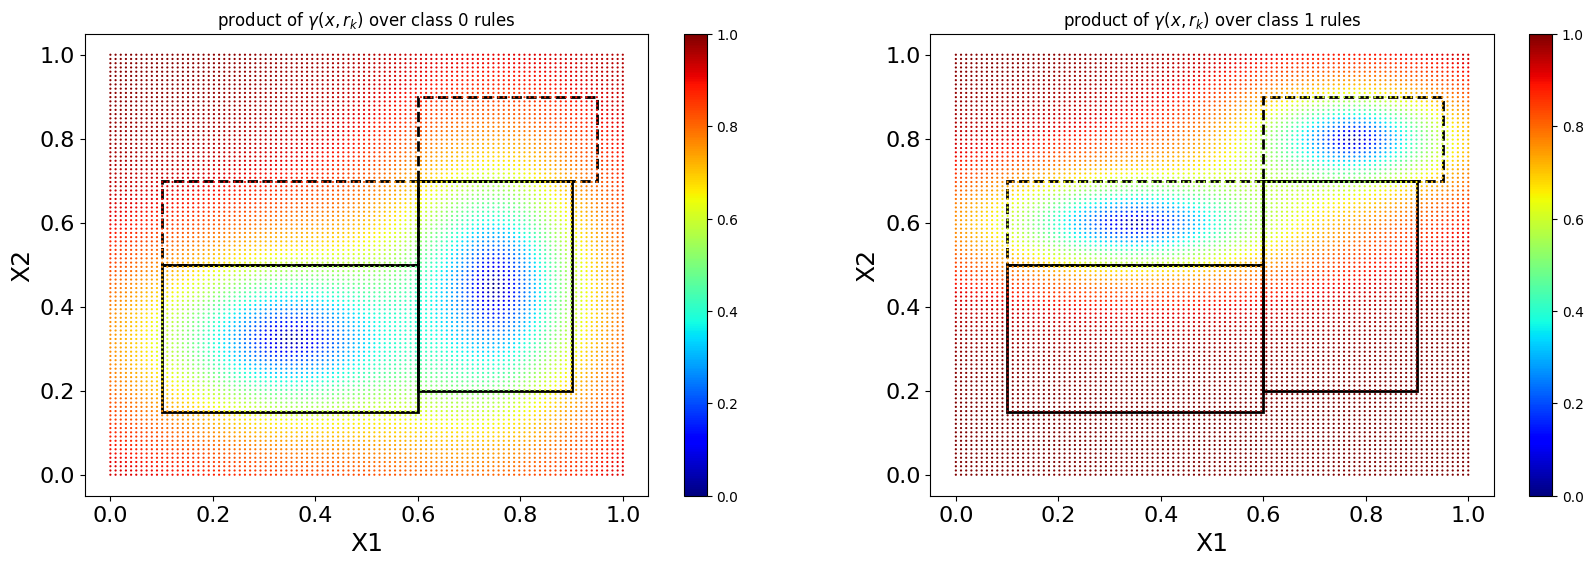

In [94]:
def compute_centerbased_gamma(rule_limits, X_r, Y_r, distance = "L2", normalization = "bounded"):

    xmin, xmax, ymin, ymax = rule_limits#0.2, 0.7, 0.3, 0.7

    cx, cy = (xmin+xmax)/2, (ymin + ymax)/2
    hx = abs(xmax - xmin)/2
    hy = abs(ymax - ymin)/2

    gamma_x = np.abs(X_r - cx) / hx
    gamma_y = np.abs(Y_r - cy) / hy
    if distance == "L2":
        tau_geom = np.sqrt((gamma_x**2 + gamma_y**2) / 2)#np.mean([gamma_x, gamma_y], axis=0) #np.zeros(X_r.shape)
    elif distance == "L1":
        tau_geom = np.mean([gamma_x, gamma_y], axis=0)
    
    if normalization == "bounded":
        tau_geom = tau_geom/(1+tau_geom) # np.tanh(tau_geom)#
    elif normalization == "tanh":
        tau_geom = np.tanh(tau_geom)


    return tau_geom

x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
X_r, Y_r = np.meshgrid(x, y)

rule_limits = [[0.1, 0.6, 0.15, 0.5], [0.6, 0.9, 0.2, 0.7], [0.1, 0.6, 0.5, 0.7], [0.6, 0.95, 0.7, 0.9]]
changeclsidx = 3
tau_geom_tot_0 = 1
for r in rule_limits[:changeclsidx-1]:
    tau_geom = compute_centerbased_gamma(r, X_r, Y_r, distance = "L2", normalization = "tanh")
    tau_geom_tot_0*=tau_geom



tau_geom_tot_1 = 1
for r in rule_limits[changeclsidx-1:]:
    tau_geom = compute_centerbased_gamma(r, X_r, Y_r, distance = "L2", normalization = "tanh")
    tau_geom_tot_1*=tau_geom


fig, (ax1, ax2) = plt.subplots(1,2,figsize = (20,6))
for idx, r in enumerate(rule_limits):
    xmin, xmax, ymin, ymax = r
    if idx < changeclsidx-1:
        ax1.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='-', facecolor='none'))
        ax2.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='-', facecolor='none'))
    else:
        ax1.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='--', facecolor='none'))
sc1 = ax1.scatter(X_r, Y_r, c=tau_geom_tot_0, cmap='jet', s=10, edgecolors='none', linewidth=1.5, marker='.', norm = norm)
cbar = plt.colorbar(sc1, ax=ax1)
ax1.set_xlabel("X1", fontsize=18)
ax1.set_ylabel("X2", fontsize=18)
ax1.tick_params(labelsize=16)
ax1.set_title(r"product of $\gamma(x, r_k)$ over class 0 rules")

sc2 = ax2.scatter(X_r, Y_r, c=tau_geom_tot_1, cmap='jet', s=10, edgecolors='none', linewidth=1.5, marker='.', norm = norm)
cbar = plt.colorbar(sc2, ax=ax2)
ax2.set_xlabel("X1", fontsize=18)
ax2.set_ylabel("X2", fontsize=18)
ax2.tick_params(labelsize=16)
ax2.set_title(r"product of $\gamma(x, r_k)$ over class 1 rules")
plt.show()

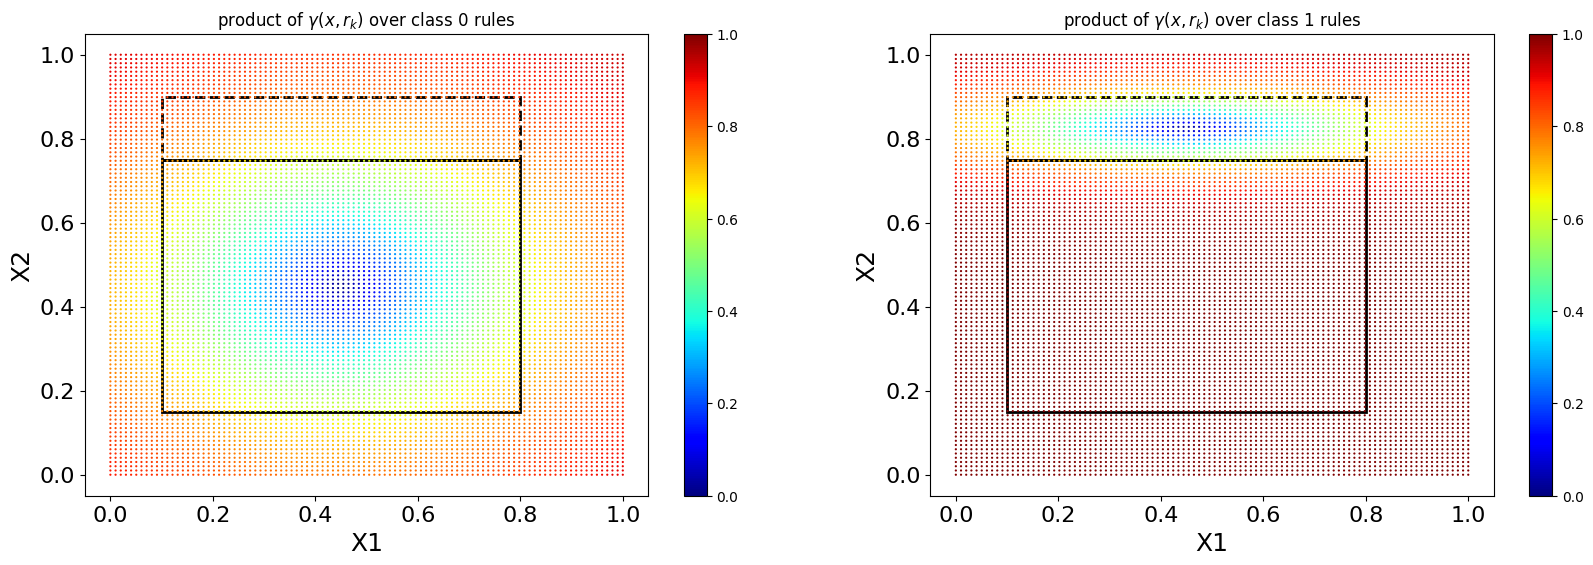

In [97]:
rule_limits = [[0.1, 0.8, 0.15, 0.75], [0.1, 0.8, 0.75, 0.9]]
changeclsidx = 2

tau_geom_tot_0 = 1
for r in rule_limits[:changeclsidx-1]:
    tau_geom = compute_centerbased_gamma(r, X_r, Y_r, distance = "L2", normalization = "tanh")
    tau_geom_tot_0*=tau_geom



tau_geom_tot_1 = 1
for r in rule_limits[changeclsidx-1:]:
    tau_geom = compute_centerbased_gamma(r, X_r, Y_r, distance = "L2", normalization = "tanh")
    tau_geom_tot_1*=tau_geom


fig, (ax1, ax2) = plt.subplots(1,2,figsize = (20,6))
for idx, r in enumerate(rule_limits):
    xmin, xmax, ymin, ymax = r
    if idx < changeclsidx-1:
        ax1.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='-', facecolor='none'))
        ax2.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='-', facecolor='none'))
    else:
        ax1.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((xmin, ymin), abs(xmax-xmin), abs(ymax-ymin), linewidth=2, edgecolor='black', linestyle='--', facecolor='none'))
sc1 = ax1.scatter(X_r, Y_r, c=tau_geom_tot_0, cmap='jet', s=10, edgecolors='none', linewidth=1.5, marker='.', norm = norm)
cbar = plt.colorbar(sc1, ax=ax1)
ax1.set_xlabel("X1", fontsize=18)
ax1.set_ylabel("X2", fontsize=18)
ax1.tick_params(labelsize=16)
ax1.set_title(r"product of $\gamma(x, r_k)$ over class 0 rules")

sc2 = ax2.scatter(X_r, Y_r, c=tau_geom_tot_1, cmap='jet', s=10, edgecolors='none', linewidth=1.5, marker='.', norm = norm)
cbar = plt.colorbar(sc2, ax=ax2)
ax2.set_xlabel("X1", fontsize=18)
ax2.set_ylabel("X2", fontsize=18)
ax2.tick_params(labelsize=16)
ax2.set_title(r"product of $\gamma(x, r_k)$ over class 1 rules")
plt.show()